<a href="https://colab.research.google.com/github/sanjyoti-gaikwad/NCC-disease-classification-ML/blob/main/Neurocysticercosis_Gene_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neurocysticercosis Gene Classification Pipeline
This version avoids data leakage. Labels are created from differential expression, but the model is trained only on expression values across samples.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score

## Upload GSE288552 count matrix

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
counts_df = pd.read_csv("GSE288552_raw.counts_all.samples.csv")
counts_df.head()


Saving GSE288552_raw.counts_all.samples.csv to GSE288552_raw.counts_all.samples.csv


,Unnamed: 0,NC1,NC2,NC3,PRE_SAT_1,PRE_SAT_2,PRE_SAT_3,PRE_AT_1,PRE_AT_2,PRE_AT_3,...,EV_SAT_3,EV_AT_1,EV_AT_2,EV_AT_3,POST_SAT_1,POST_SAT_2,POST_SAT_3,POST_AT_1,POST_AT_2,POST_AT_3
0,TsM_000000100,48,37,31,31,29,67,36,30,30,...,14,30,36,14,18,40,48,43,18,17
1,TsM_000000200,215,274,200,341,429,803,387,441,303,...,187,233,448,201,193,479,415,401,239,149
2,TsM_000000300,16,12,11,63,77,157,40,50,54,...,42,74,80,47,69,317,197,62,34,18
3,TsM_000000400,9,9,8,6,5,8,9,5,8,...,6,12,26,8,5,4,15,7,12,9
4,TsM_000000500,67,104,69,62,92,142,84,103,65,...,80,93,177,57,90,236,183,125,66,40


In [ ]:
gene_ids = counts_df.iloc[:,0]
expr = counts_df.iloc[:,1:].copy()
expr = expr.apply(pd.to_numeric)
controls = ['NC1','NC2','NC3']
disease = [c for c in expr.columns if c not in controls]
print('Genes:', len(expr))
print('Controls:', len(controls))
print('Disease samples:', len(disease))


Genes: 12356
Controls: 3
Disease samples: 18


## Create gene labels (for target only)

In [ ]:
labels=[]
for _, row in expr.iterrows():
    ctrl=row[controls].values.astype(float)
    dis=row[disease].values.astype(float)
    log2fc=np.log2((np.mean(dis)+1)/(np.mean(ctrl)+1))
    pval=ttest_ind(dis,ctrl,equal_var=False).pvalue
    label=1 if (abs(log2fc)>1 and pval<0.05) else 0
    labels.append(label)
y=np.array(labels)
print(pd.Series(y).value_counts())


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment 

0    10957
1     1399
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment 

In [ ]:
labels

[0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,


## Features = expression values only (no leakage)

In [ ]:
X = np.log2(expr.values + 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## KMeans clustering

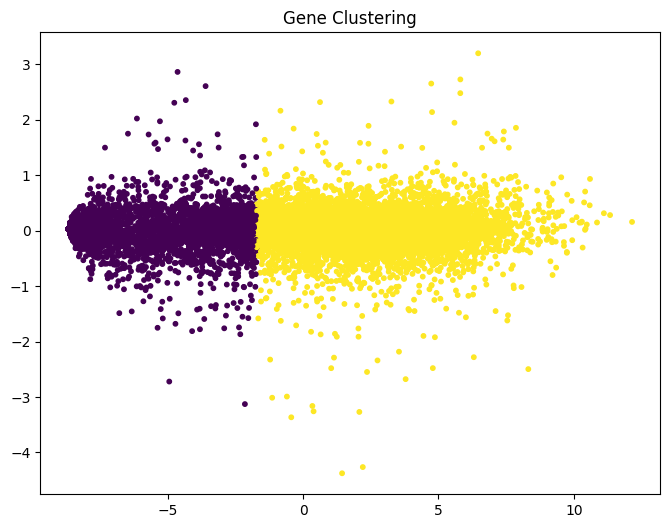

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=10)
plt.title('Gene Clustering')
plt.show()


## Stratified 5-Fold Cross Validation


---



In [ ]:
# Stratified 5-Fold Cross Validation

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_cv,
    X_scaled,
    y,
    cv=skf,
    scoring='accuracy'
)

print("Fold Accuracies:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Fold Accuracies:
[0.95873786 0.96398219 0.95386483 0.96155403 0.95426953]

Mean Accuracy:
0.9584816885581482

Standard Deviation:
0.00397034292612283


## Random Forest classifier

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,y,test_size=0.2,random_state=42,stratify=y)
rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(X_train,y_train)
pred=rf.predict(X_test)
print('Accuracy:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.9571197411003236
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2192
           1       0.97      0.64      0.77       280

    accuracy                           0.96      2472
   macro avg       0.96      0.82      0.87      2472
weighted avg       0.96      0.96      0.95      2472



## Predict all genes

In [ ]:
all_predictions = rf.predict(X_scaled)
results = pd.DataFrame({
    'Gene': gene_ids,
    'Prediction': np.where(all_predictions==1,
    'Disease_Associated','Not_Disease_Associated')
})
results.head()


,Gene,Prediction
0,TsM_000000100,Not_Disease_Associated
1,TsM_000000200,Not_Disease_Associated
2,TsM_000000300,Disease_Associated
3,TsM_000000400,Not_Disease_Associated
4,TsM_000000500,Not_Disease_Associated


## Query a specific gene

In [ ]:
gene_name='TsM_000000100'
print(results[results['Gene']==gene_name])


            Gene              Prediction
0  TsM_000000100  Not_Disease_Associated


In [ ]:
results.to_csv('gene_classification_results.csv',index=False)
print('Saved gene_classification_results.csv')


Saved gene_classification_results.csv


#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[2186    6]
 [ 100  180]]


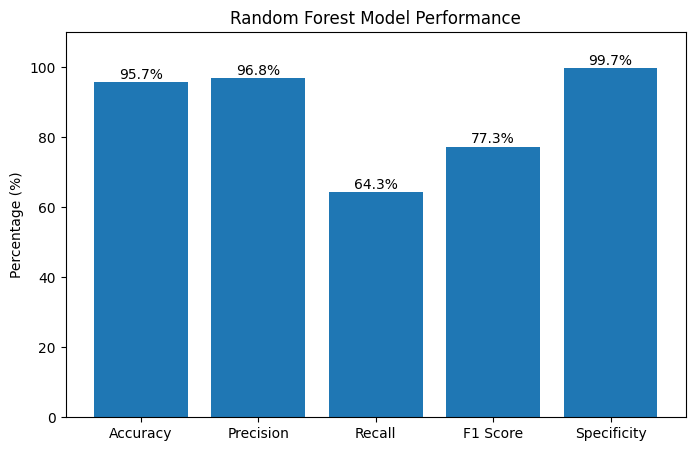

In [ ]:
import matplotlib.pyplot as plt

metrics = {
    "Accuracy": 95.7,
    "Precision": 96.8,
    "Recall": 64.3,
    "F1 Score": 77.3,
    "Specificity": 99.7
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8,5))
bars = plt.bar(names, values)

plt.ylim(0, 110)
plt.ylabel("Percentage (%)")
plt.title("Random Forest Model Performance")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f"{yval:.1f}%",
        ha='center'
    )

plt.show()

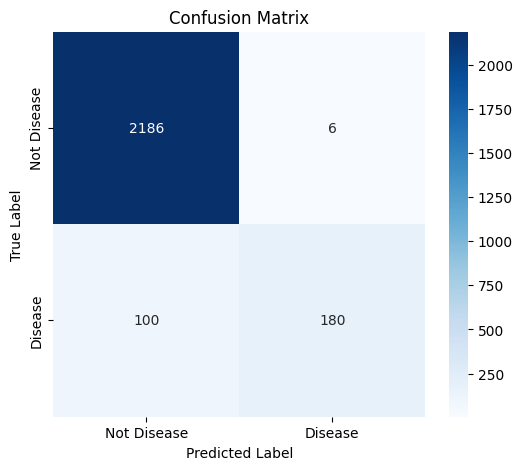

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = [[2186, 6],
      [100, 180]]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Disease", "Disease"],
    yticklabels=["Not Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()